In [72]:
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import PcmPy as pcm
from Pcm import find_model
import globals as gl
from Plot import add_colorbar, set_spines_and_ticks_width, set_dark_background

from util import r_squared
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('default')
plt.style.use('dark_background')

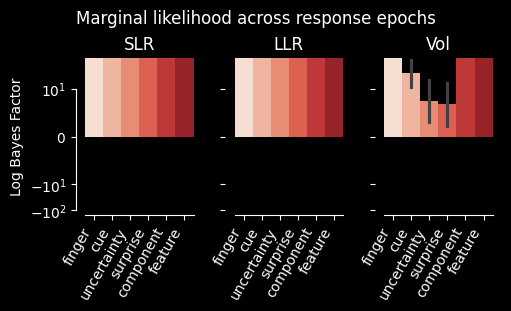

In [73]:
epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 3), sharey=True, constrained_layout=True)

vmin, vmax = -.1, 1.1

for r, epoch in enumerate(epochs):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Reds',
                    errorbar='se')
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.set_ylim((-150, 150))
    ax.spines[['left',]].set_bounds(-10**2, 10)
    ax.set_yticks([-10**2, -10, 0, 10, ])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
    ax.tick_params(axis='y', which='minor', left=False)

    ax.set_xlim(-1, 6)
    ax.spines[['bottom',]].set_bounds(-.5, 5.5)

    ax.set_title(f'{epoch}')

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)

    else:
        ax.spines[['top', 'right','left']].set_visible(False)

fig.suptitle('Marginal likelihood across response epochs')

plt.show()

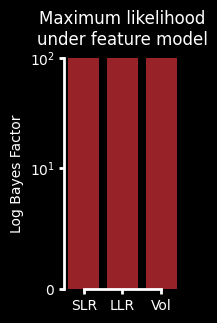

In [74]:
plt.style.use('dark_background')

epochs = ['SLR', 'LLR', 'Vol',]
experiment = 'smp0'

LL = {
    'epoch': [],
    'noise_upper': [],
    'noise_lower': [],
    'baseline': [],
    'likelihood': [],
}
for r, epoch in enumerate(epochs):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.pkl'))

    # Subtract the baseline
    LL['likelihood'].extend(T_cv.likelihood.loc[:,'feature'])
    LL['baseline'].extend(T_cv.likelihood.loc[:,'null'])
    LL['epoch'].extend([epoch] * len(T_cv.likelihood.loc[:,'feature']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood.loc[:, 'ceil'])

LL = pd.DataFrame(LL)
baseline = LL.loc[:,'baseline'].values
LL[['noise_upper', 'noise_lower', 'likelihood']] = LL[['noise_upper', 'noise_lower', 'likelihood']] - baseline.reshape(-1,1)
# LL['likelihood_norm'] = LL['likelihood'] / LL['noise_lower']

fig, ax = plt.subplots(figsize=(1.5, 3))

width = .8

color = sns.color_palette('Reds', n_colors=6)[-1]
ax = sns.barplot(data=LL, x='epoch', y='likelihood', ax=ax, width=width, errorbar='se', color=color)

for r, epoch in enumerate(epochs):
    noise_upper = LL[LL['epoch'] == epoch]['noise_upper'].mean()
    noise_lower = LL[LL['epoch'] == epoch]['noise_lower'].mean()
    # ratio = noise_upper / noise_lower
    noiserect = Rectangle((r-width/2, noise_lower), width,noise_upper - noise_lower, linewidth=0, facecolor=[0.5, 0.5, 0.5, 0.2], zorder=1e6, alpha=.3)
    ax.add_patch(noiserect)

ax.set_yscale('symlog', linthresh=10)
ax.set_ylim(0, 100)
ax.set_xticks(ax.get_xticks())
ax.set_ylabel('Log Bayes Factor')
ax.set_xlabel('')
ax.spines[['top', 'right',]].set_visible(False)
ax.spines[['bottom','left']].set_linewidth(2)
ax.spines[['left',]].set_bounds([0, 100])
ax.spines[['bottom',]].set_bounds([0, 2])
ax.tick_params(width=2)

ax.set_title('Maximum likelihood\nunder feature model', pad=10)

plt.show()


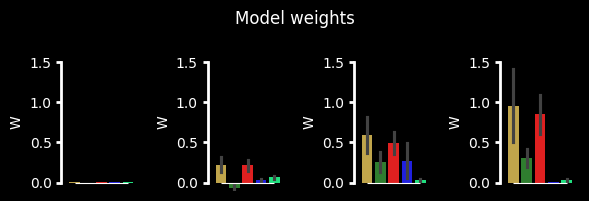

In [80]:
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
experiment = 'smp0'
plt.style.use('dark_background')

features = np.array(['finger', 'interaction','cue', 'uncertainty', 'surprise'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

Ac = Mf.Ac.sum(axis=0)
n_param = Mf.n_param

vmin, vmax = -0, .001

colors = sns.color_palette("Set3", n_colors=5) #+ [(.5, .5, .5)]
#colors = np.array(colors)[np.array([0, 4, 1, 2, 3])]

fig, axs = plt.subplots(1, len(epochs), figsize=(6, 2))

for r, epoch in enumerate(epochs):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.pkl'), "rb")

    # Bottom row: bar plot
    row_ax = axs[r]
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta2 = theta**2
    var_expl = np.vstack([theta2[0,] + theta2[1,], theta[1,] * theta[2,], theta2[2,] + theta2[3,], theta2[4,], theta2[5,]])

    sns.barplot(data=var_expl.T, ax=row_ax, palette=['#D4AF37', 'forestgreen', 'red', 'blue', 'springgreen'], errorbar='se')

    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    row_ax.hlines(0, 0, 4, color='w', lw=0.8)
    row_ax.set_xlim((-1, 5))
    row_ax.set_ylim((-.1, 1.6))
    row_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    row_ax.spines[['left',]].set_bounds(0, 1.5)
    row_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # if r == 0:
    row_ax.set_ylabel('W')
    row_ax.spines[['bottom','left']].set_linewidth(2)
    row_ax.tick_params(width=2)

fig.suptitle('Model weights')

fig.tight_layout()

plt.show()

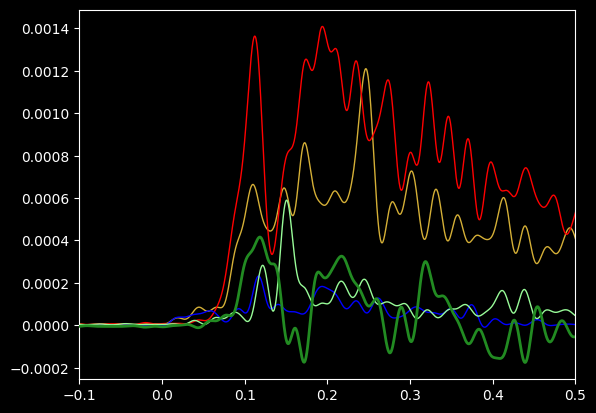

In [76]:
from util import lp_filter

theta = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.continuous.npy'))
T = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.continuous.npy'))[..., 6]
G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.continuous.npy'))

tr = np.trace(G_obs, axis1=-2, axis2=-1)

latency = .05

# Preprocess theta
theta2 = theta ** 2
var_expl = np.array([theta2[..., 0] + theta2[..., 1], theta[..., 1] * theta[..., 2] , theta2[..., 2] + theta2[..., 3], theta2[..., 4], theta2[..., 5]])
var_expl_filtered = lp_filter(var_expl, 50, 2148)

N = theta.shape[0]
tAx = np.linspace(-1, 2, theta2.shape[1]) - latency

# Set up figure
fig, ax = plt.subplots()

color = ['#D4AF37', 'forestgreen', 'red', 'blue', 'palegreen']

for v, var in enumerate(var_expl_filtered):
    if v==1:
        ax.plot(tAx, var.mean(axis=0), color=color[v], lw=2, zorder=1e6)
    else:
        ax.plot(tAx, var.mean(axis=0), color=color[v], lw=1)

ax.set_xlim([-.1, .5])

plt.show()
# ax.set_yscale('symlog')

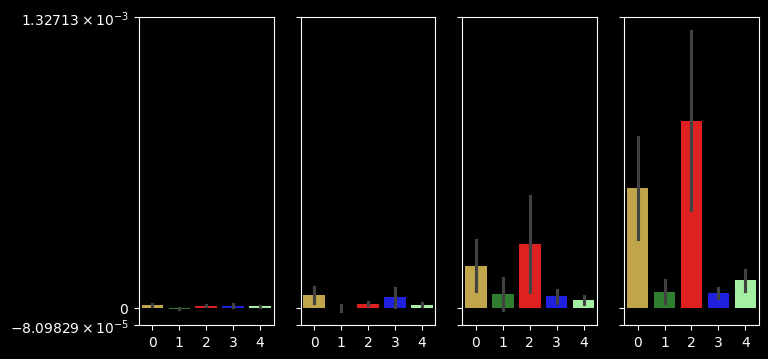

In [77]:
wins = [(-1.0, 0.0), (.025, .05), (.05, .1), (.1, .5)]
epochs = ['Pre', 'SLR', 'LLR', 'Vol']

fs = 2148
latency = .05 * fs
onset = int(1 * fs + latency)

fig, axs = plt.subplots(1, 4, figsize=(8, 4), sharey=True)

for w, win in enumerate(wins):
    var_expl_avg = var_expl[..., int(onset + win[0] * fs):int(onset + win[1] * fs)].mean(axis=-1)

    sns.barplot(data=var_expl_avg.T, ax=axs[w], errorbar='se', palette=['#D4AF37', 'forestgreen', 'red', 'blue', 'springgreen'])

for ax in axs:
    ax.set_yscale('symlog')
    pass

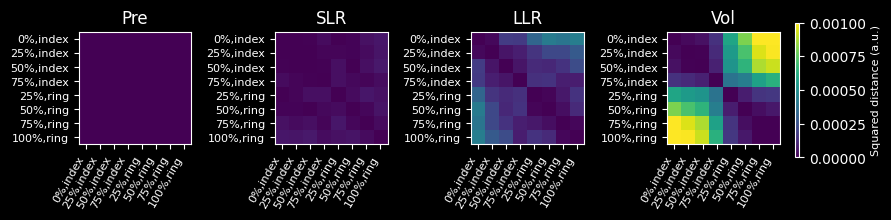

In [78]:


vmin, vmax = -0., .001

wins = [(-1.0, 0.0), (.025, .05), (.05, .1), (.1, .5)]
epochs = ['Pre', 'SLR', 'LLR', 'Vol']

fs = 2148
latency = .05 * fs
onset = int(1 * fs + latency)

fig, axs = plt.subplots(1, 4, figsize=(8, 4))

for w, win in enumerate(wins):
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epochs[w]}.npy'))
    D = pcm.G_to_dist(G_obs.mean(axis=(0,)))

    ax = axs[w]

    cax = ax.imshow(D, vmin=vmin, vmax=vmax)
    ax.set_title(epochs[w])

    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)
    ax.set_xticks(ax.get_yticks())
    ax.set_xticklabels(ax.get_yticklabels(), fontsize=8, rotation=60, ha='right')

# Colorbar for imshow (top row)
bbox = axs[0].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('Squared distance (a.u.)', fontsize=8)

fig.tight_layout()

plt.show()